# KF M1+M9 EnbPI：Oracle benchmark

這是獨立的比較實驗，不會覆蓋原本的 `KF_m1m9_EnbPI.ipynb`。Oracle 使用真正的 M1、M9 方程式與真實上一期高低頻狀態，但不知道下一期 innovation，因此是不可實際部署的理想基準。

In [6]:
import importlib
import pandas as pd
import kf_enbpi
import kf_oracle_benchmark
import numpy  as np
importlib.reload(kf_enbpi)
importlib.reload(kf_oracle_benchmark)

from kf_enbpi import EnbPIConfig, simulate_and_run, monte_carlo_summary
from kf_oracle_benchmark import (
    oracle_comparison_table, oracle_monte_carlo_summary,
    plot_oracle_comparison, plot_representative_oracle_run,
)
pd.set_option('display.precision', 4)
print('Loaded:', kf_enbpi.__file__)
print('Loaded:', kf_oracle_benchmark.__file__)

Loaded: c:\Users\User\Desktop\程式\project\meeting\kf_enbpi.py
Loaded: c:\Users\User\Desktop\程式\project\meeting\kf_oracle_benchmark.py


## 與原 M1M9 相同的 EnbPI 設定
Oracle 不參與訓練或區間建構，只在相同測試資料上提供條件平均 RMSE 基準。

In [2]:
config = EnbPIConfig(
    window_size=15, alpha=0.05, n_bootstrap=30, block_length=None,
    batch_size=1, beta_grid_size=101, oob_bias_correction=True,
    arima_order=None, arima_max_p=4, arima_max_q=4,
    ann_hidden_layers=(32, 16), ann_max_iter=500, ann_alpha=1e-4,
    ann_learning_rate_init=1e-3, ann_target_standardization=True,
    ann_early_stopping=False, ann_rolling_validation=True,
    ann_rolling_splits=3, ann_validation_fraction=0.10,
    ann_iteration_candidates=(125, 250, 500), ann_tol=1e-3,
    random_state=1234,
)
train_size = 650
horizon = 50

## 單次實驗：Hybrid 與 Oracle

,model,hybrid_observed_rmse,oracle_observed_rmse,hybrid_minus_oracle_rmse,hybrid_to_oracle_rmse_ratio,hybrid_clean_rmse,oracle_clean_rmse,theoretical_oracle_observed_rmse,theoretical_oracle_clean_rmse
0,M1M9,2.0952,1.9498,0.1454,1.0746,2.0777,1.9245,1.7791,1.7727


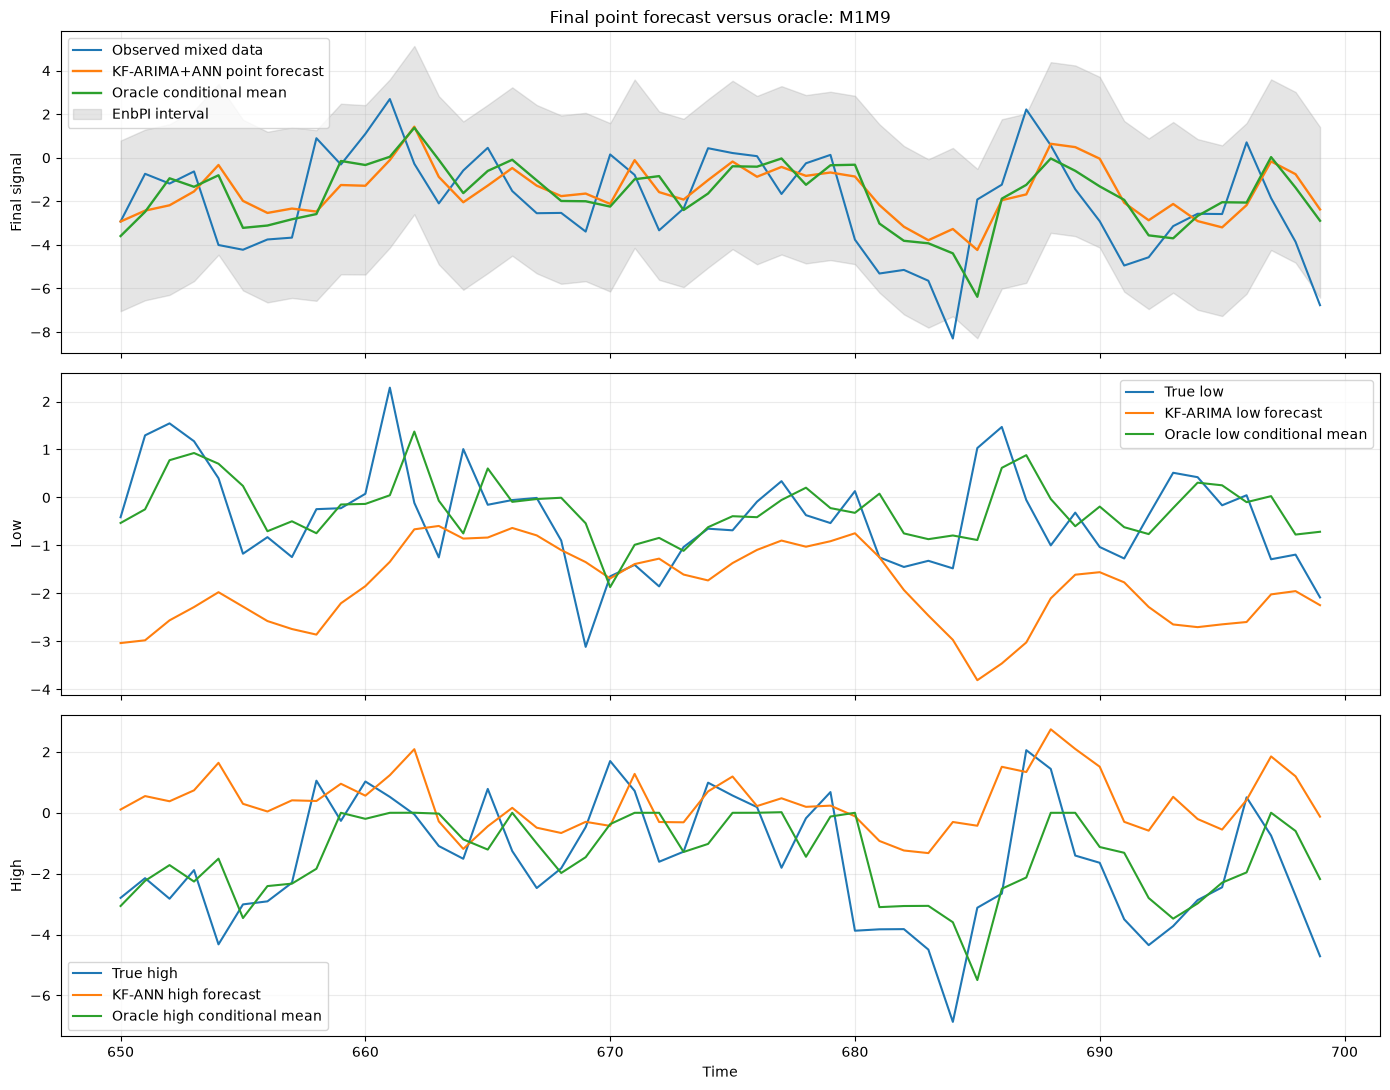

In [3]:
result = simulate_and_run(
    'm1m9', train_size=train_size, horizon=horizon, config=config, data_seed=2026
)
display(oracle_comparison_table(result, 'm1m9'))
plot_oracle_comparison(result, 'm1m9');

## Monte Carlo Oracle 比較
`hybrid_minus_oracle_rmse` 越接近 0，代表 Hybrid 越接近已知真實方程式下的理想預測器。

,metric,mean,std
0,mse,3.5806,1.0650
1,rmse,1.8744,0.2658
2,coverage,0.9520,0.0321
3,mean_width,7.5677,0.3199
4,low_kf_mse,0.2125,0.0766
5,low_kf_rmse,0.4544,0.0799
6,high_kf_mse,2.2893,0.6566
7,high_kf_rmse,1.4999,0.2042
8,low_true_mse,3.6239,2.1635
9,low_true_rmse,1.8436,0.4869


,metric,mean,std
0,hybrid_observed_rmse,1.8744,0.2658
1,oracle_observed_rmse,1.7630,0.2452
2,hybrid_minus_oracle_rmse,0.1114,0.1087
3,hybrid_to_oracle_rmse_ratio,1.0642,0.0624
4,hybrid_clean_rmse,1.8604,0.2651
5,oracle_clean_rmse,1.7508,0.2397
6,theoretical_oracle_observed_rmse,1.8562,0.0860
7,theoretical_oracle_clean_rmse,1.8501,0.0863


,run,data_seed,hybrid_observed_rmse,oracle_observed_rmse,hybrid_minus_oracle_rmse,hybrid_to_oracle_rmse_ratio,hybrid_clean_rmse,oracle_clean_rmse,theoretical_oracle_observed_rmse,theoretical_oracle_clean_rmse
0,1,479243620,1.6077,1.6810,-0.0733,0.9564,1.5670,1.6419,1.7038,1.6972
1,2,454024514,1.7187,1.6233,0.0954,1.0588,1.7291,1.6412,1.8203,1.8141
2,3,1818751028,1.7226,1.6210,0.1016,1.0627,1.7633,1.6605,1.7677,1.7613
3,4,2288458700,2.3291,2.1771,0.1520,1.0698,2.3126,2.1588,1.8403,1.8342
4,5,2115331525,1.7011,1.5283,0.1728,1.1131,1.6750,1.5106,1.8792,1.8732
5,6,2666256175,2.0861,1.7194,0.3666,1.2132,2.0852,1.7172,1.9739,1.9682
6,7,975381835,1.5960,1.5416,0.0544,1.0353,1.5787,1.5298,1.7841,1.7778
7,8,2535166222,2.1953,1.9209,0.2744,1.1428,2.1596,1.8871,1.9183,1.9124
8,9,1079577930,1.6301,1.4851,0.1450,1.0977,1.5931,1.4599,1.8783,1.8723
9,10,3715024065,2.0704,1.8320,0.2384,1.1301,2.0555,1.8123,1.9424,1.9366


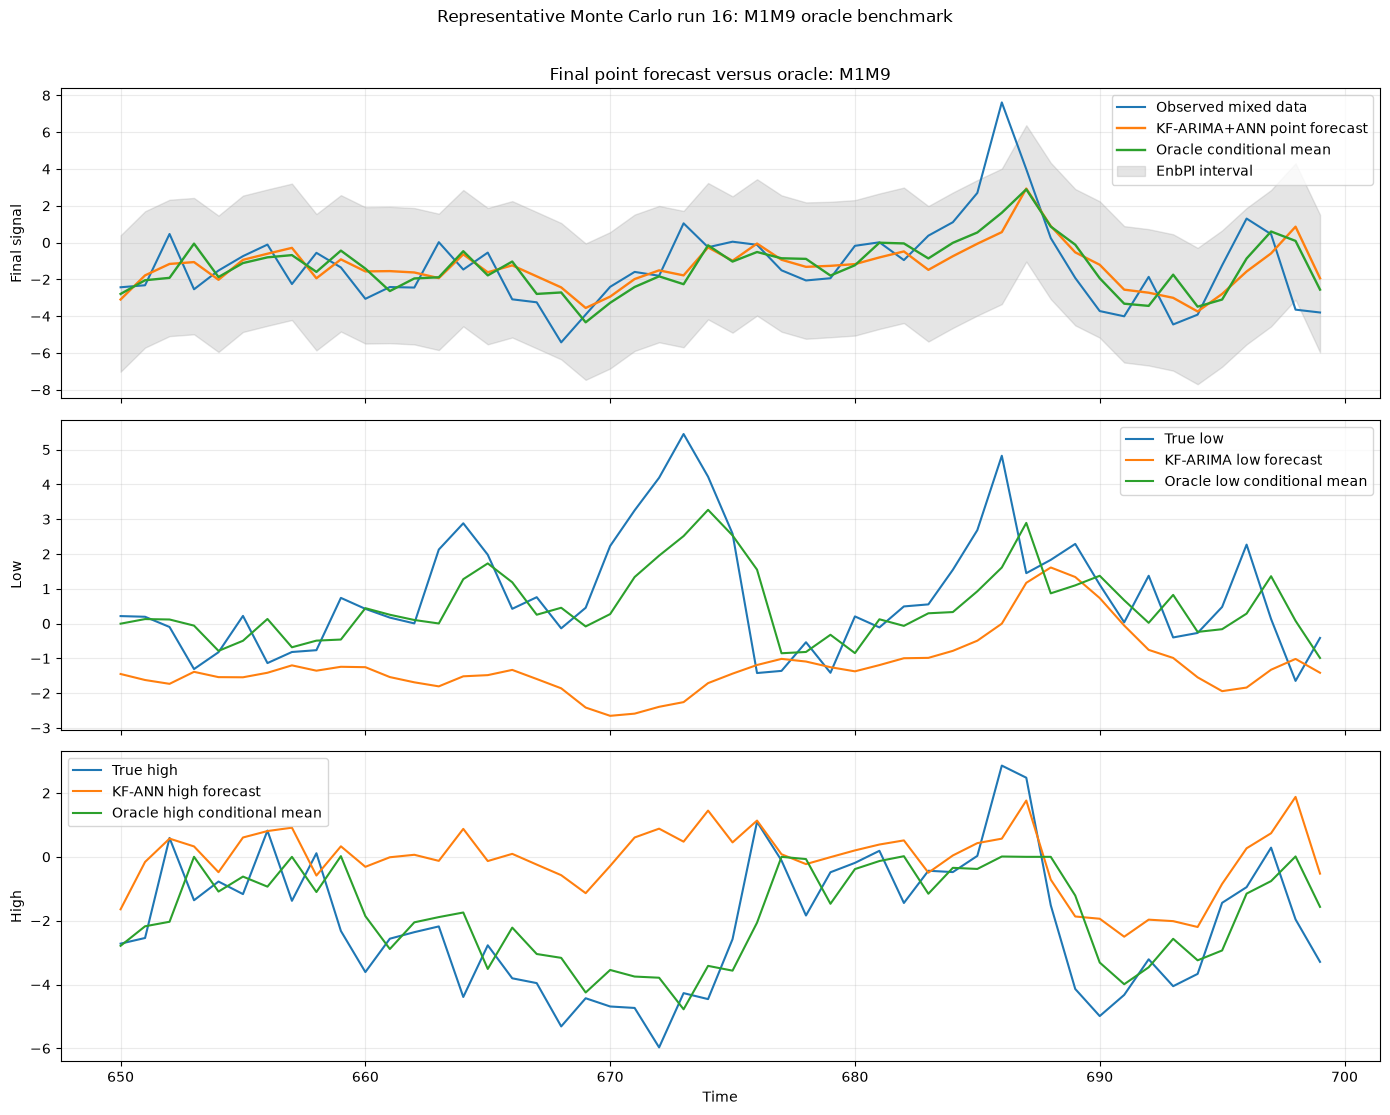

In [4]:
runs, enbpi_summary, mc_results = monte_carlo_summary(
    'm1m9', n_runs=20, train_size=train_size, horizon=horizon,
    config=config, seed=2026,
)
oracle_runs, oracle_summary = oracle_monte_carlo_summary(
    runs, mc_results, 'm1m9'
)
display(enbpi_summary)
display(oracle_summary)
display(oracle_runs)
plot_representative_oracle_run(runs, mc_results, 'm1m9');